# Tarea 1 --- IELE756: Demographic Profile & Migration Landscape
**Team members**: Darío Ampuero, Nicolás Véliz
**Comunas asignadas**: Recoleta + Independencia + Padre Hurtado + San Pedro
**Date**: 26 de marzo de 2026

## Part 0: Data Loading & Joins
En esta sección cargaremos exclusivamente las columnas sugeridas de las tablas de viviendas, hogares y personas del Censo 2024 para optimizar la memoria. Luego filtraremos por nuestras comunas asignadas y realizaremos un cruce de datos (Left Join), verificando que la unidad de observación se mantenga a nivel de persona.

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 0.1 Definir las columnas exactas que pide la tarea
cols_viv = ["id_vivienda", "region", "comuna", "p4a_mat_paredes"]
cols_hog = ["id_vivienda", "id_hogar", "p12_tenencia_viv"]
cols_per = ["id_vivienda", "id_hogar", "id_persona", "sexo", "edad",
            "p27_nacionalidad_esp", "p25_lug_nacimiento_rec", "p24_lug_resid5",
            "p25_lug_nacimiento", "p26_llegada_periodo", "escolaridad", "cine11",
            "sit_fuerza_trabajo", "cod_ciuo", "cod_caenes", "p45_medio_transporte"]

print("Cargando archivos Parquet...")
vivienda = pd.read_parquet("viviendas_censo2024.parquet", columns=cols_viv)
hogar = pd.read_parquet("hogares_censo2024.parquet", columns=cols_hog)
persona = pd.read_parquet("personas_censo2024.parquet", columns=cols_per)

# 0.2 Filtrar por tus comunas
MY_COMUNAS = [13124, 13111, 13606, 13504] # Recoleta, Independencia, Padre Hurtado, San Pedro (Melipilla)

viv = vivienda[vivienda["comuna"].isin(MY_COMUNAS)]
hog = hogar[hogar["id_vivienda"].isin(viv["id_vivienda"])]
per = persona[persona["id_vivienda"].isin(viv["id_vivienda"])]

# 0.3 Join (Cruce de tablas)
df = per.merge(hog, on=["id_vivienda", "id_hogar"], how="left") \
        .merge(viv, on="id_vivienda", how="left")

# Añadir un mapeo por nombre de comuna
comuna_names = {13124: "Recoleta", 13111: "Independencia", 13606: "Padre Hurtado", 13504: "San Pedro"}
df['nombre_comuna'] = df['comuna'].map(comuna_names)

# Verificar que no se hayan duplicado ni perdido filas
assert len(df) == len(per), "Row count mismatch after join!"
print(f"Cruce exitoso. Forma del DataFrame final: {df.shape}")

# Limpiar edades no válidas (-99) para el resto del análisis
df_clean = df[df["edad"] != -99].copy()

# Mapear p25_lug_nacimiento_rec códigos númericos para strings descriptivos
nac_rec_map = {1: 'Chile', 2: 'Extranjero', -99: 'No especificado'}
df_clean['p25_lug_nacimiento_rec'] = df_clean['p25_lug_nacimiento_rec'].map(nac_rec_map).fillna('Otro')

# El .astype(str) no es estrictamente necesario para el mapeo de los strings, pero se conserva para dar más robustez
df_clean['p25_lug_nacimiento_rec'] = df_clean['p25_lug_nacimiento_rec'].astype(str)

Cargando archivos Parquet...
Cruce exitoso. Forma del DataFrame final: (355194, 21)


## Part 1: Demographic Profile
Calculamos la Tasa de Dependencia y construimos una pirámide poblacional superponiendo la población nacida en Chile vs. nacida en el extranjero. Además, analizamos el tamaño del hogar, la escolaridad promedio (25+ años) y la tasa de empleo (15-64 años).

$$\text{Dependency ratio} = \frac{\text{population aged 0-14} + \text{population aged 65+}}{\text{population aged 15-64}}$$

Tasa de Dependencia por Comuna:


/tmp/ipykernel_19122/1435070942.py:8: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  display(df_clean.groupby("nombre_comuna").apply(calc_dependency).reset_index(name="Dependency Ratio"))


,nombre_comuna,Dependency Ratio
0,Independencia,49.864212
1,Recoleta,42.864310
2,San Pedro,52.210986


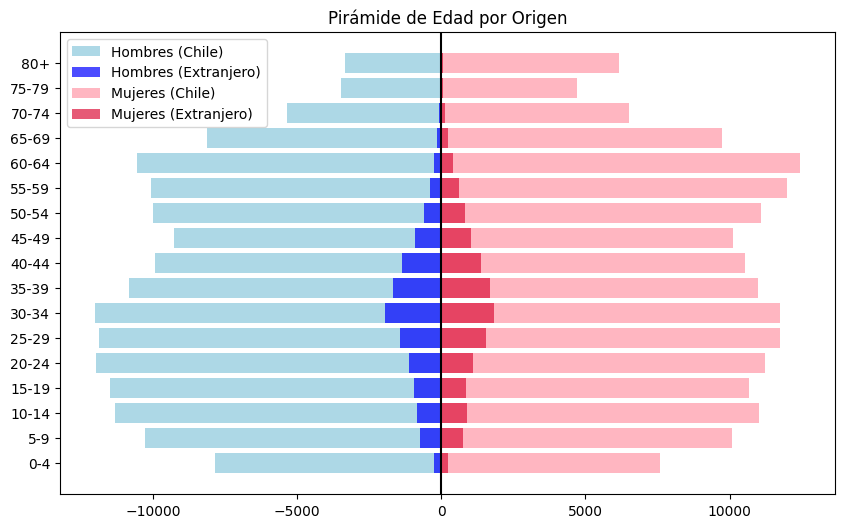

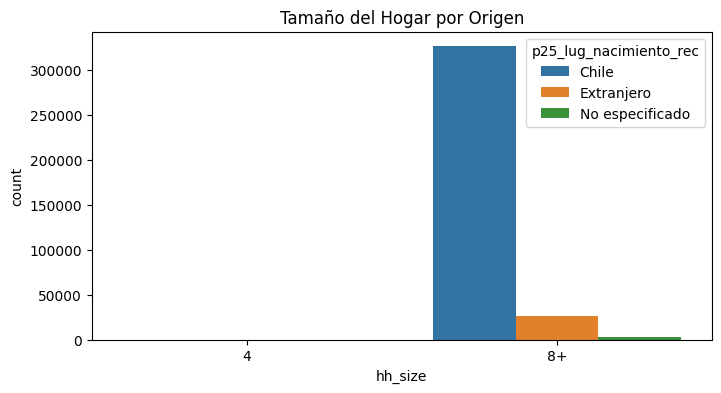

/tmp/ipykernel_19122/1435070942.py:41: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  emp_rate = df_1564.groupby(['nombre_comuna', 'p25_lug_nacimiento_rec']).apply(lambda x: (x['sit_fuerza_trabajo'] == 1).mean() * 100).unstack()


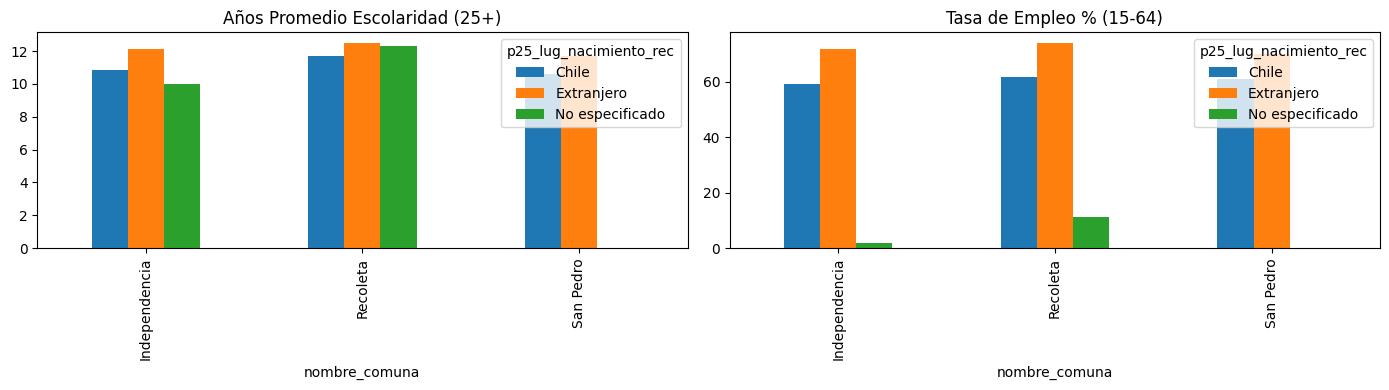

In [27]:
# --- 1.2 Dependency Ratio ---
def calc_dependency(group):
    jovenes_mayores = len(group[(group["edad"] <= 14) | (group["edad"] >= 65)])
    activos = len(group[(group["edad"] >= 15) & (group["edad"] <= 64)])
    return (jovenes_mayores / activos) * 100 if activos > 0 else np.nan

print("Tasa de Dependencia por Comuna:")
display(df_clean.groupby("nombre_comuna").apply(calc_dependency).reset_index(name="Dependency Ratio"))

# --- 1.1 Age Pyramid ---
bins = list(range(0, 81, 5)) + [200]
labels = [f"{i}-{i+4}" for i in range(0, 80, 5)] + ["80+"]
df_clean["age_group"] = pd.cut(df_clean["edad"], bins=bins, labels=labels, right=False)

h_ch = df_clean[(df_clean["sexo"] == 1) & (df_clean["p25_lug_nacimiento_rec"].str.contains("Chile", na=False))]["age_group"].value_counts().sort_index()
h_ex = df_clean[(df_clean["sexo"] == 1) & (df_clean["p25_lug_nacimiento_rec"].str.contains("Extranjero", na=False))]["age_group"].value_counts().sort_index()
m_ch = df_clean[(df_clean["sexo"] == 2) & (df_clean["p25_lug_nacimiento_rec"].str.contains("Chile", na=False))]["age_group"].value_counts().sort_index()
m_ex = df_clean[(df_clean["sexo"] == 2) & (df_clean["p25_lug_nacimiento_rec"].str.contains("Extranjero", na=False))]["age_group"].value_counts().sort_index()

plt.figure(figsize=(10, 6))
y = np.arange(len(labels))
plt.barh(y, -h_ch, color='lightblue', label='Hombres (Chile)')
plt.barh(y, -h_ex, color='blue', label='Hombres (Extranjero)', alpha=0.7)
plt.barh(y, m_ch, color='lightpink', label='Mujeres (Chile)')
plt.barh(y, m_ex, color='crimson', label='Mujeres (Extranjero)', alpha=0.7)
plt.yticks(y, labels); plt.axvline(0, color='black'); plt.legend(); plt.title('Pirámide de Edad por Origen')
plt.show()

# --- 1.3 Household Size ---
df_clean['hh_size_num'] = df_clean.groupby('id_hogar')['id_persona'].transform('count')
df_clean['hh_size'] = np.where(df_clean['hh_size_num'] >= 8, '8+', df_clean['hh_size_num'].astype(str))
plt.figure(figsize=(8, 4))
sns.countplot(data=df_clean.sort_values('hh_size_num'), x='hh_size', hue='p25_lug_nacimiento_rec')
plt.title('Tamaño del Hogar por Origen'); plt.show()

# --- 1.4 Education & Employment ---
df_25 = df_clean[(df_clean['edad'] >= 25) & (df_clean['escolaridad'] != -99)]
edu_mean = df_25.groupby(['nombre_comuna', 'p25_lug_nacimiento_rec'])['escolaridad'].mean().unstack()

df_1564 = df_clean[(df_clean['edad'] >= 15) & (df_clean['edad'] <= 64)]
emp_rate = df_1564.groupby(['nombre_comuna', 'p25_lug_nacimiento_rec']).apply(lambda x: (x['sit_fuerza_trabajo'] == 1).mean() * 100).unstack()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
edu_mean.plot(kind='bar', ax=axes[0], title='Años Promedio Escolaridad (25+)')
emp_rate.plot(kind='bar', ax=axes[1], title='Tasa de Empleo % (15-64)')
plt.tight_layout(); plt.show()

## Part 2: Migration Landscape
Analizamos el porcentaje de población extranjera, el top 10 de nacionalidades, su lugar de residencia hace 5 años y la distribución de su período de llegada a Chile.

Porcentaje de Extranjeros por Comuna:


/tmp/ipykernel_19122/1426462757.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  pct_foreign = df_clean.groupby('nombre_comuna').apply(lambda x: (x['p25_lug_nacimiento_rec'].str.contains('Extranjero', na=False)).mean() * 100).reset_index(name='% Extranjeros')


,nombre_comuna,% Extranjeros
0,Independencia,8.525111
1,Recoleta,7.244755
2,San Pedro,2.318916


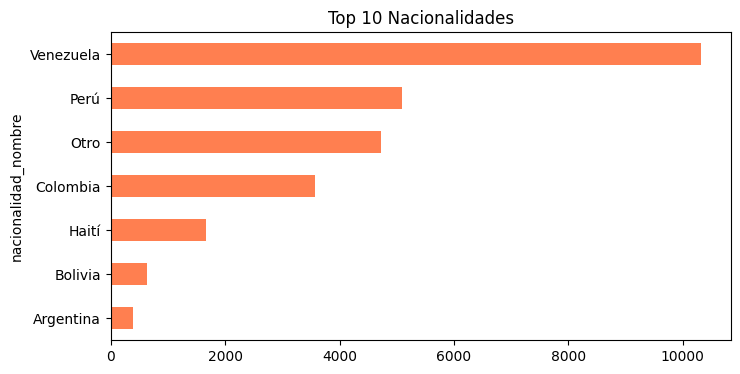

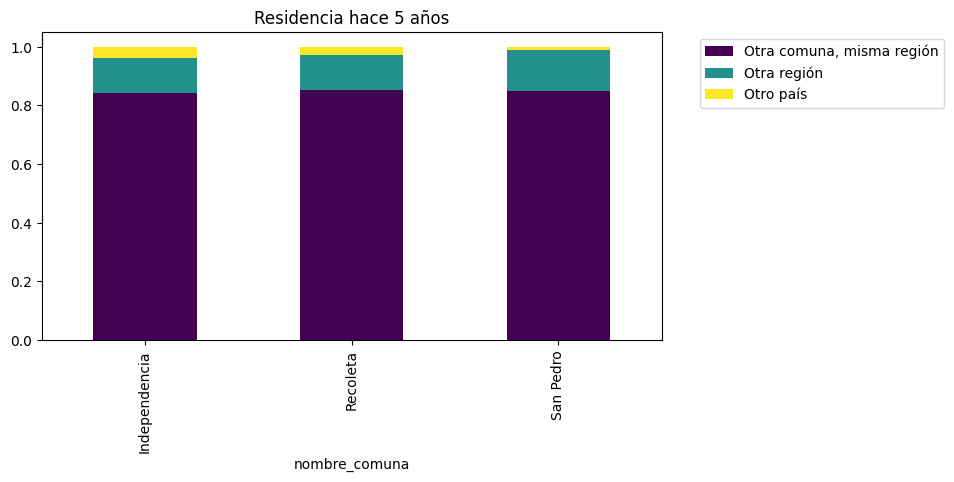

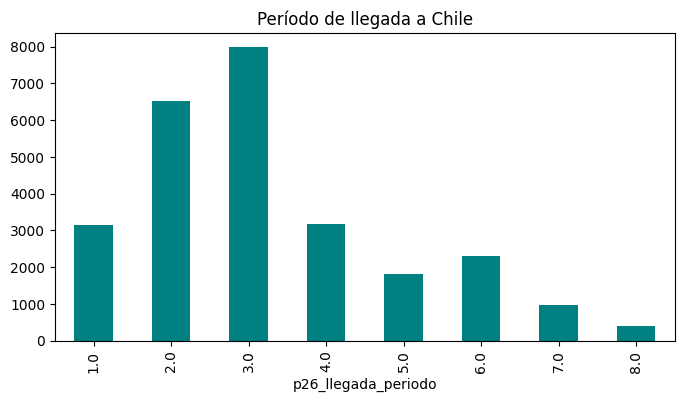

In [28]:
# --- 2.1 % Foreign-born ---
pct_foreign = df_clean.groupby('nombre_comuna').apply(lambda x: (x['p25_lug_nacimiento_rec'].str.contains('Extranjero', na=False)).mean() * 100).reset_index(name='% Extranjeros')
print("Porcentaje de Extranjeros por Comuna:"); display(pct_foreign)

# --- 2.2 Top 10 Nationalities ---
nac_dict = {862: 'Venezuela', 170: 'Colombia', 604: 'Perú', 332: 'Haití', 68: 'Bolivia', 32: 'Argentina', 218: 'Ecuador'}
df_foreign = df_clean[df_clean['p25_lug_nacimiento_rec'].str.contains('Extranjero', na=False)].copy()
df_foreign['nacionalidad_nombre'] = df_foreign['p27_nacionalidad_esp'].map(nac_dict).fillna('Otro')

plt.figure(figsize=(8, 4))
df_foreign['nacionalidad_nombre'].value_counts().head(10).sort_values().plot(kind='barh', color='coral')
plt.title('Top 10 Nacionalidades'); plt.show()

# --- 2.3 Migration Status (Residencia hace 5 años) ---
res_dict = {1: 'Misma comuna', 2: 'Otra comuna, misma región', 3: 'Otra región', 4: 'Otro país'}
df_5yrs = df_clean[(df_clean['edad'] >= 5) & (df_clean['p24_lug_resid5'] != -99)].copy()
df_5yrs['resid5_nombre'] = df_5yrs['p24_lug_resid5'].map(res_dict)

pd.crosstab(df_5yrs['nombre_comuna'], df_5yrs['resid5_nombre'], normalize='index').plot(kind='bar', stacked=True, figsize=(8, 4), colormap='viridis')
plt.title('Residencia hace 5 años'); plt.legend(bbox_to_anchor=(1.05, 1)); plt.show()

# --- 2.4 Arrival Period ---
llegada = df_foreign[df_foreign['p26_llegada_periodo'] > 0]['p26_llegada_periodo'].value_counts().sort_index()
llegada.plot(kind='bar', figsize=(8, 4), color='teal', title='Período de llegada a Chile'); plt.show()

## Part 3: Spatial Visualization
Mapeo coroplético de nuestras comunas asignadas usando Geopandas.

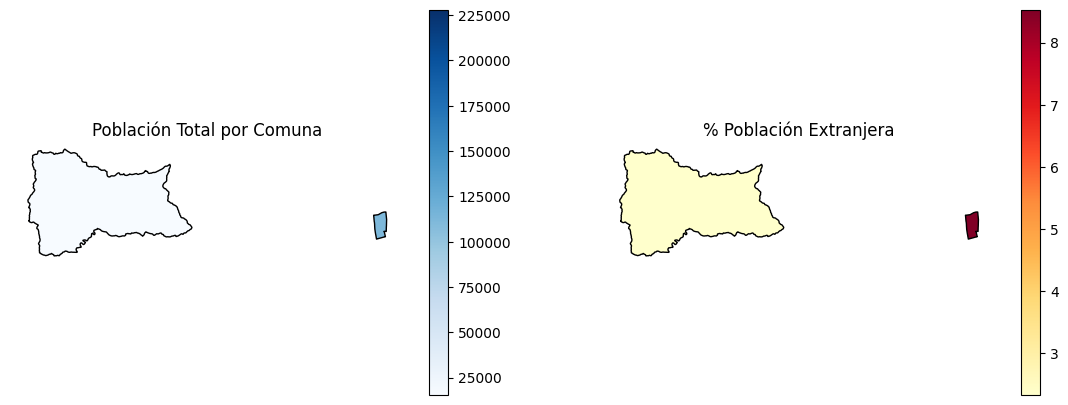

In [29]:
import geopandas as gpd

try:
    comunas_gdf = gpd.read_file("comunas.shp")

    # Intenta con nombres comunes para las columnas de códigos de comuna, o inspecciona `comunas_gdf.columns` para encontrar el correcto.
    # Por ejemplo, podría ser 'COD_COMUNA', 'CUT', 'COMUNA', etc.
    # Encontramos 'cod_comuna' en las columnas disponibles, así que lo usaremos.
    if 'CUT' in comunas_gdf.columns:
        comunas_gdf['codigo_comu'] = pd.to_numeric(comunas_gdf['CUT'], errors='coerce')
    elif 'COD_COMUNA' in comunas_gdf.columns:
        comunas_gdf['codigo_comu'] = pd.to_numeric(comunas_gdf['COD_COMUNA'], errors='coerce')
    elif 'cod_comuna' in comunas_gdf.columns: # Se añadió esta condición
        comunas_gdf['codigo_comu'] = pd.to_numeric(comunas_gdf['cod_comuna'], errors='coerce') # Usar 'cod_comuna'
    else:
        print("No se encontró una columna de código de comuna común (CUT o COD_COMUNA).")
        print("Columnas disponibles en comunas_gdf:", comunas_gdf.columns.tolist())
        raise KeyError("Columna de código de comuna no encontrada. Por favor, verifica comunas_gdf.columns.")

    map_data = df_clean.groupby('comuna').agg(
        pop_total=('id_persona', 'count'),
        pct_foreign=('p25_lug_nacimiento_rec', lambda x: (x.str.contains('Extranjero', na=False)).mean() * 100)
    ).reset_index()

    map_merged = comunas_gdf.merge(map_data, left_on='codigo_comu', right_on='comuna', how='inner')

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    map_merged.plot(column='pop_total', ax=axes[0], legend=True, cmap='Blues', edgecolor='black')
    axes[0].set_title('Población Total por Comuna'); axes[0].axis('off')

    map_merged.plot(column='pct_foreign', ax=axes[1], legend=True, cmap='YlOrRd', edgecolor='black')
    axes[1].set_title('% Población Extranjera'); axes[1].axis('off')
    plt.show()
except FileNotFoundError:
    print("Sube los archivos comunas.shp, comunas.shx y comunas.dbf para ver el mapa.")
except KeyError as e:
    print(f"Error de columna: {e}. Por favor, asegúrate de que el nombre de la columna para los códigos de comuna es correcto en tu shapefile.")

## Part 4: Comuna-Level Summary Table
Tabla resumen agregada a nivel comunal, separando indicadores entre chilenos y extranjeros.

In [30]:
import os

def build_summary(g):
    ch = g[g['p25_lug_nacimiento_rec'].str.contains('Chile', na=False)]
    ex = g[g['p25_lug_nacimiento_rec'].str.contains('Extranjero', na=False)]

    med_age_ch = ch['edad'].median()
    med_age_ex = ex['edad'].median()

    esc_ch = ch[(ch['edad'] >= 25) & (ch['escolaridad'] != -99)]['escolaridad'].mean()
    esc_ex = ex[(ex['edad'] >= 25) & (ex['escolaridad'] != -99)]['escolaridad'].mean()

    emp_ch = ch[(ch['edad'] >= 15) & (ch['edad'] <= 64)]
    emp_ex = ex[(ex['edad'] >= 15) & (ex['edad'] <= 64)]

    activos = len(g[(g['edad'] >= 15) & (g['edad'] <= 64)])
    dep_ratio = (len(g[(g['edad'] <= 14) | (g['edad'] >= 65)]) / activos) * 100 if activos > 0 else np.nan

    return pd.Series({
        'nombre_comuna': g['nombre_comuna'].iloc[0],
        'pop_total': len(g),
        'pop_chilean': len(ch),
        'pop_foreign': len(ex),
        'pct_foreign': (len(ex) / len(g)) * 100 if len(g) > 0 else 0,
        'median_age_chilean': med_age_ch,
        'median_age_foreign': med_age_ex,
        'mean_schooling_chilean': esc_ch,
        'mean_schooling_foreign': esc_ex,
        'emp_rate_chilean': (emp_ch['sit_fuerza_trabajo'] == 1).mean() * 100 if len(emp_ch) > 0 else np.nan,
        'emp_rate_foreign': (emp_ex['sit_fuerza_trabajo'] == 1).mean() * 100 if len(emp_ex) > 0 else np.nan,
        'dependency_ratio': dep_ratio
    })

summary = df_clean.groupby('comuna').apply(build_summary).reset_index()

os.makedirs('output', exist_ok=True)
summary.to_csv('output/tarea1_comuna_summary.csv', index=False)
print("¡Tabla exportada a output/tarea1_comuna_summary.csv!")
display(summary)

¡Tabla exportada a output/tarea1_comuna_summary.csv!


/tmp/ipykernel_19122/3270749120.py:34: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  summary = df_clean.groupby('comuna').apply(build_summary).reset_index()


,comuna,nombre_comuna,pop_total,pop_chilean,pop_foreign,pct_foreign,median_age_chilean,median_age_foreign,mean_schooling_chilean,mean_schooling_foreign,emp_rate_chilean,emp_rate_foreign,dependency_ratio
0,13111,Independencia,112022,101705,9550,8.525111,39.0,32.0,10.856734,12.150499,59.303517,72.057525,49.864212
1,13124,Recoleta,227820,209560,16505,7.244755,37.0,33.0,11.680918,12.513129,61.827243,74.204123,42.864310
2,13504,San Pedro,15352,14959,356,2.318916,38.0,32.0,10.592101,11.698276,61.002045,70.212766,52.210986
